# Module 03: EDA

In [41]:
# packages
import numpy as np 
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots
from sklearn.model_selection import train_test_split 
from ISLP import load_data

# set seed
seed = 2323

### We'll use the _Hitters_ data from ISLP for this activity. The metadata for _Hitters_ can be found [here](https://intro-stat-learning.github.io/ISLP/datasets/Hitters.html).

In [42]:
# Load the data
Hitters = load_data('Hitters')

### Determine the number of rows and columns in the dataset by returning its "shape" attribute

In [43]:
Hitters.shape

(322, 20)

### Determine whether each feature is numeric or categorical by returning the "dtype" attribute for each column

In [44]:
for col in Hitters.columns:
    t = Hitters.dtypes[col]
    print(t)

int64
int64
int64
int64
int64
int64
int64
int64
int64
int64
int64
int64
int64
category
category
int64
int64
int64
float64
category


### Before doing any other analyses, let's create training and test sets.

In [45]:
Train, Test = train_test_split(Hitters, 
                               random_state=seed, 
                               test_size=0.40, 
                               shuffle=True) 

### Based on the metadata, what is the difference between the 6 columns starting with 'C' and the 6 related columns that don't?

The 6 columns that start with 'C" refer to counts across the hitters entire career while the related columns counted only in 1986.

### On the training set, create pairwise scatterplots for each of these 6 columns with the 'Salary' variable.

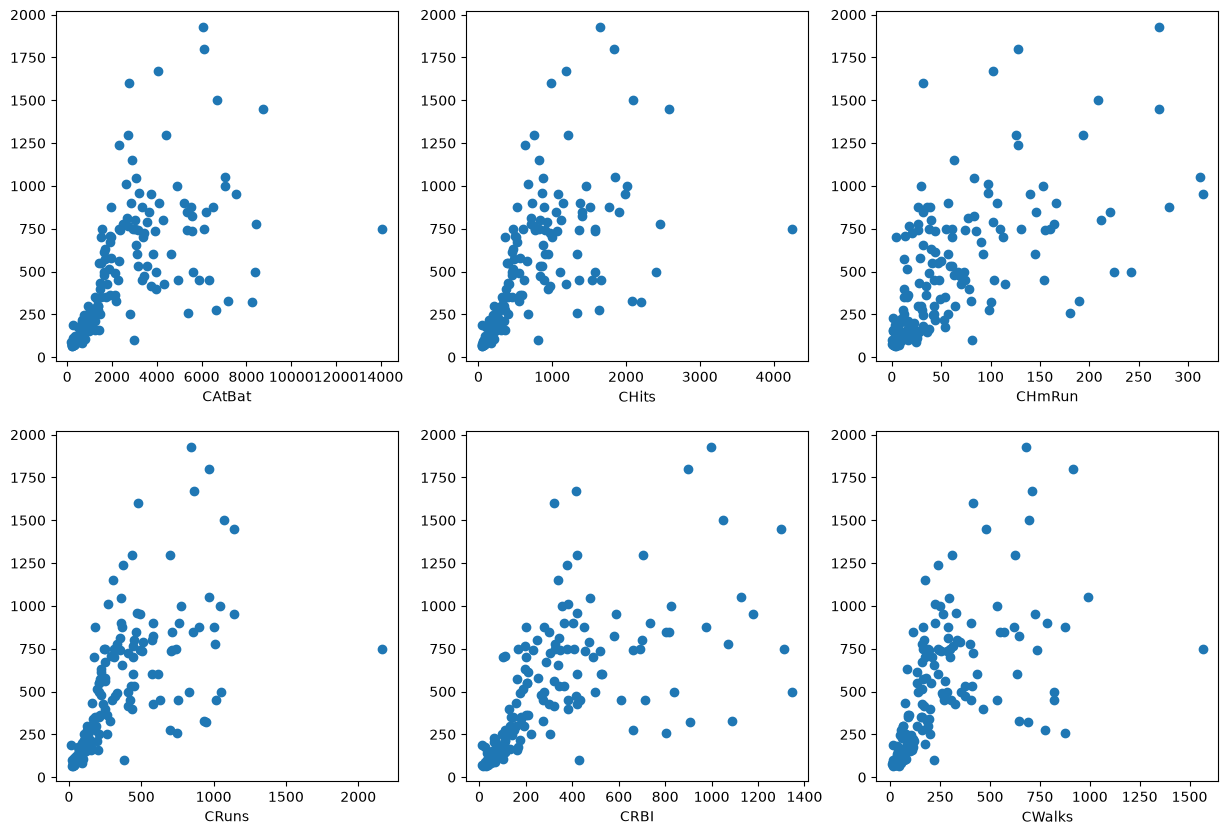

In [46]:
# First create a subset of the columns that we want to plot

subset = Train[['CAtBat', 'CHits', 'CHmRun', 'CRuns', 'CRBI', 'CWalks']]

# Initialize the plots before drawing them

fig, axes = subplots(nrows=2,
                     ncols=3,
                     figsize=(15, 10))
# Copy the helper function

def range_to_grid(i,Ncol):
    x=[]
    y=[]
    for n in range(Ncol**2):
        x.append(int(np.floor(n/Ncol)))
        y.append(n % Ncol)
        #print(n,x[n],y[n])
    return x[i],y[i]

# Plot the variables

for j in range(len(subset.columns)):
    axes[range_to_grid(j,3)[0],range_to_grid(j,3)[1]].plot(subset.iloc[:,j], Train['Salary'], 'o')
    axes[range_to_grid(j,3)[0],range_to_grid(j,3)[1]].set_xlabel(subset.columns[j])


### Use the "describe" method to determine the mean, standard deviation, and 5 number summary of all numeric variables in the training subset of _Hitters_.

In [47]:
summary = subset.describe().loc[["mean", "std", "min", "25%", "50%", "75%", "max"]]

print(summary)

            CAtBat        CHits      CHmRun        CRuns         CRBI  \
mean   2587.440415   702.222798   59.668394   345.378238   308.373057   
std    2285.947344   649.010165   66.449102   322.848870   297.885894   
min      41.000000    13.000000    0.000000     3.000000     4.000000   
25%     730.000000   185.000000   14.000000    98.000000    82.000000   
50%    1876.000000   476.000000   36.000000   238.000000   202.000000   
75%    3754.000000  1000.000000   78.000000   494.000000   419.000000   
max   14053.000000  4256.000000  315.000000  2165.000000  1348.000000   

           CWalks  
mean   248.388601  
std    250.777436  
min      4.000000  
25%     63.000000  
50%    166.000000  
75%    332.000000  
max   1566.000000  


### It looks like the mean and median of 'AtBat' are nearly equal. This _might_ suggest that this variable is normally distributed. Create a histogram of 'AtBat' to check this hypothesis.

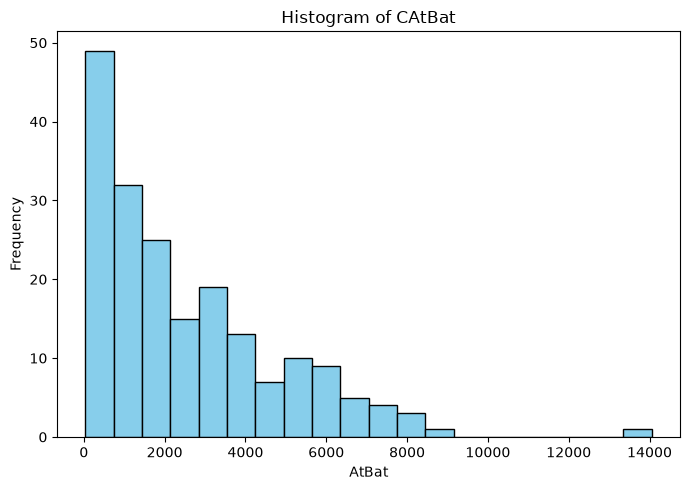

In [48]:
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(7, 5))


# Helper function from your template
def range_to_grid(i, Ncol):
    x = []
    y = []
    for n in range(Ncol**2):
        x.append(int(np.floor(n / Ncol)))
        y.append(n % Ncol)
    return x[i], y[i]


# Plot only 'AtBat'
axes.hist(
    subset["CAtBat"].dropna(), bins=20, color="skyblue", edgecolor="black"
)
axes.set_title("Histogram of CAtBat")
axes.set_xlabel("AtBat")
axes.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

### Let's standardize the AtBat feature (i.e., normalize by z-scores). We'll create a new column in the training data called 'AtBat_st' to represent this.

In [49]:
Train["AtBat_st"] = (Train["AtBat"] - Train["AtBat"].mean()) / Train["AtBat"].std(ddof=1)


### How many rows have an 'AtBat' value within the first standard deviation?

Hint: the 'len' magic method returns the number of rows of a dataFrame.

In [50]:

within_1std = Train[(Train["AtBat_st"] >= -1) & (Train["AtBat_st"] <= 1)]
num_rows = len(within_1std)

print(num_rows)

115


### Going back to the results of the 'describe' method, how can you tell that the 'Salary' variable has missing values?


You can tell that the salary variable is msising values by returning the count which represents the number of full rows in the given variable colomn. The salary count is 263 while the other variable counts are 322. 

In [51]:
summary = Hitters.describe().loc[["count", "mean", "std", "min", "25%", "50%", "75%", "max"]]

print(summary)#fillin Type your answer here.

            AtBat        Hits       HmRun        Runs         RBI       Walks  \
count  322.000000  322.000000  322.000000  322.000000  322.000000  322.000000   
mean   380.928571  101.024845   10.770186   50.909938   48.027950   38.742236   
std    153.404981   46.454741    8.709037   26.024095   26.166895   21.639327   
min     16.000000    1.000000    0.000000    0.000000    0.000000    0.000000   
25%    255.250000   64.000000    4.000000   30.250000   28.000000   22.000000   
50%    379.500000   96.000000    8.000000   48.000000   44.000000   35.000000   
75%    512.000000  137.000000   16.000000   69.000000   64.750000   53.000000   
max    687.000000  238.000000   40.000000  130.000000  121.000000  105.000000   

            Years       CAtBat        CHits      CHmRun        CRuns  \
count  322.000000    322.00000   322.000000  322.000000   322.000000   
mean     7.444099   2648.68323   717.571429   69.490683   358.795031   
std      4.926087   2324.20587   654.472627   86.26606

### Describe a situation where a variable could have missing values but this would not be reflected in the results of the 'describe' method.

This could occur if some sort of place holder such as '0' was put in the rows that had missing data.

### On the training data, create separate boxplots of the 'AtBat' variable for when 'Salary' is populated or missing.

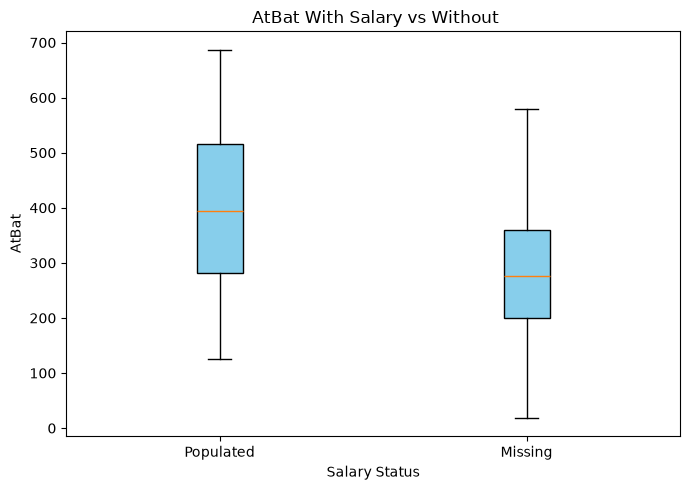

In [53]:


atbat_populated = Train[Train["Salary"].notna()]["AtBat"].dropna()
atbat_missing = Train[Train["Salary"].isna()]["AtBat"].dropna()


fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(7, 5))


def range_to_grid(i, Ncol):
    x = []
    y = []
    for n in range(Ncol**2):
        x.append(int(np.floor(n / Ncol)))
        y.append(n % Ncol)
    return x[i], y[i]



axes.boxplot(
    [atbat_populated, atbat_missing],
    tick_labels=["Populated", "Missing"],
    patch_artist=True,
    boxprops=dict(facecolor="skyblue"),
)

axes.set_title(" AtBat With Salary vs Without")
axes.set_xlabel("Salary Status")
axes.set_ylabel("AtBat")

plt.tight_layout()
plt.show()

### Create a correlation matrix for all numeric features in the training set

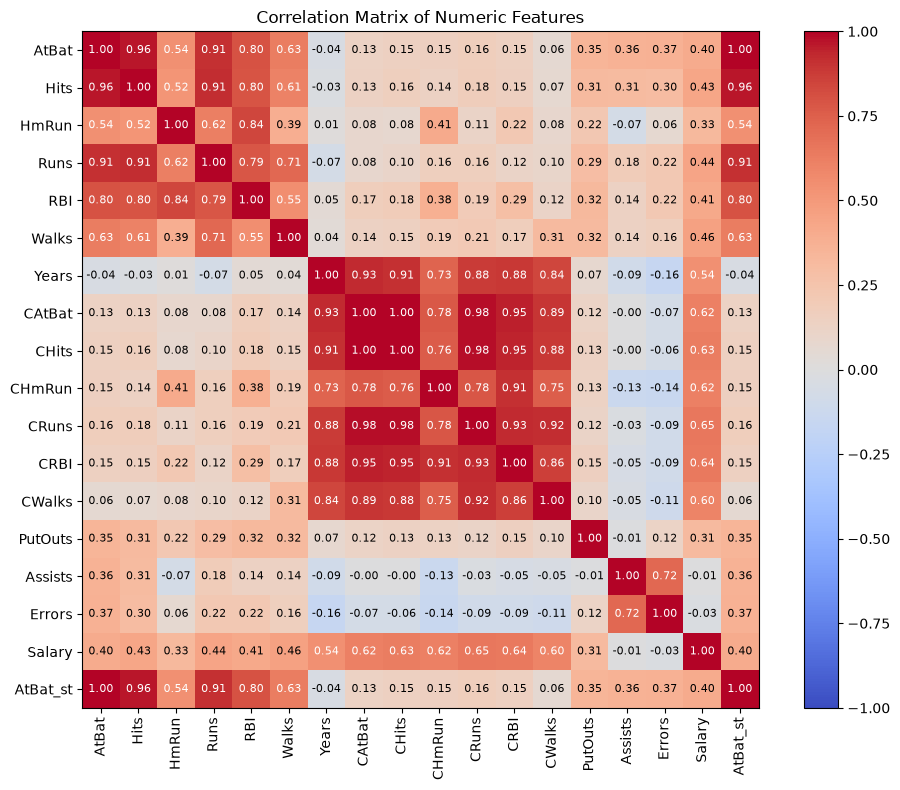

In [54]:
import matplotlib.pyplot as plt
import numpy as np


numeric_df = Train.select_dtypes(include=["number"])
corr_matrix = numeric_df.corr()

fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(10, 8))


def range_to_grid(i, Ncol):
    x = []
    y = []
    for n in range(Ncol**2):
        x.append(int(np.floor(n / Ncol)))
        y.append(n % Ncol)
    return x[i], y[i]



cax = axes.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)

fig.colorbar(cax, ax=axes)


axes.set_xticks(range(len(corr_matrix.columns)))
axes.set_yticks(range(len(corr_matrix.columns)))
axes.set_xticklabels(
    corr_matrix.columns, rotation=90
)  
axes.set_yticklabels(corr_matrix.columns)


for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        val = corr_matrix.iloc[i, j]
        axes.text(
            j,
            i,
            f"{val:.2f}",
            ha="center",
            va="center",
            color="black" if -0.5 < val < 0.5 else "white",
            fontsize=8,
        )

axes.set_title("Correlation Matrix of Numeric Features")

plt.tight_layout()
plt.show()

### Propose two different ways of imputing the missing values of Salary while taking advantage of the information given in the boxplots or the correlation matrix.

The boxplot indicates that those whose salarys were missing tended to have lower AtBat numbers. Using this information, we could smooth using the median based on AtBat numbers. So, we could create equal width bins based on AtBat numbers and fill in missing data points with the median of their respective bin. 

The correlation map indicates that Salary is correlated highly with the Career features. Thus, we could build a predictive model that estimates salary based on the values of the Career features and use it to fill in the mising data points. 

### For our last exercise, we'll explore Hits and Walks relative to AtBat totals. 
- Use the sum function to calculuate the totals of each of these three variables for the 1986 season (on the training set). 
- Create a pie chart which shows total hits, total walks, and remaining total (neither) as percents of the At Bats total (on the training set). 

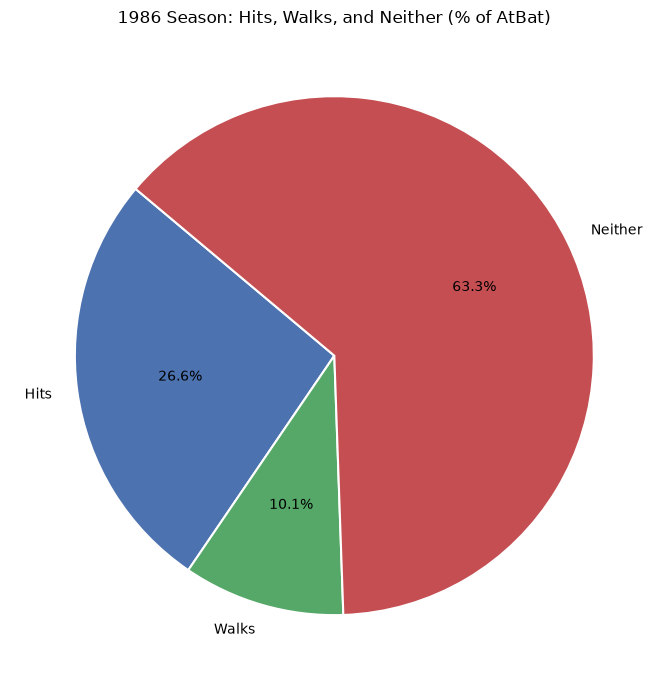

In [55]:

TotHits = Train["Hits"].sum()
TotWalks = Train["Walks"].sum()
TotAtBat = Train["AtBat"].sum()
TotNeither = TotAtBat - (TotHits + TotWalks)


Labels = ["Hits", "Walks", "Neither"] 
Totals = [TotHits, TotWalks, TotNeither]
colors = ["#4C72B0", "#55A868", "#C44E52"]


fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(7, 7))


axes.pie(
    Totals,
    labels=Labels,
    autopct="%1.1f%%",
    startangle=140,
    colors=colors,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5},
)

axes.set_title("1986 Season: Hits, Walks, and Neither (% of AtBat)")

plt.tight_layout()
plt.show()

### The previous two cells gave us totals across all players. For each player in the training set, calculate the Hits as a percent of AtBat and store it in a new variable called 'AVG'

In [56]:

Train["AVG"] = Train["Hits"] / Train["AtBat"]

print(Train[["AtBat", "Hits", "AVG"]].head())

     AtBat  Hits       AVG
3      496   141  0.284274
63     216    53  0.245370
27     474   129  0.272152
130    306   104  0.339869
93     511   138  0.270059


### Using 0.25 and 0.31 as the split points, create a new variable with three bins: high, medium, and low. 

In [57]:
Train["AVG_bin"] = "medium"
Train["AVG_bin"][Train["AVG"] < 0.25] = "low"
Train["AVG_bin"][Train["AVG"] >= 0.31] = "high"

/var/folders/3l/d2wqd3j527j4ykdhdl7jlc1c0000gn/T/ipykernel_86510/1551464325.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Train["AVG_bin"][Train["AVG"] < 0.25] = "low"
/var/folders/3l/d2wqd3j527j4ykdhdl7jlc1c0000gn/T/ipykernel_86510/1551464325.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Train["AVG_bin"][Train["AVG"] >= 0.31] = "high"


### Create a bar chart that displays the number of players in each of the low, medium, and high categories (for the training data).


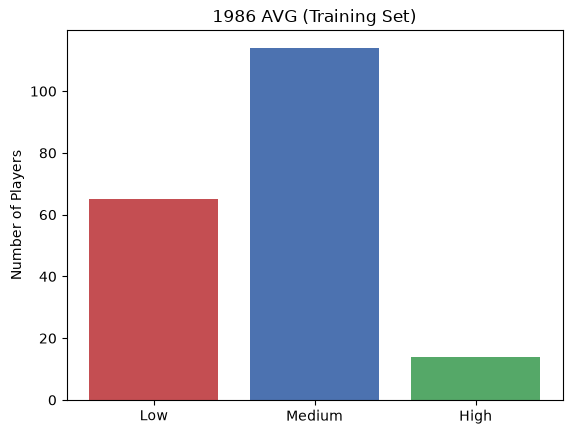

In [58]:


# 1. Update AVG_bin using .loc to avoid chained assignment warnings
Train["AVG_bin"] = "medium"
Train.loc[Train["AVG"] < 0.25, "AVG_bin"] = "low"
Train.loc[Train["AVG"] >= 0.31, "AVG_bin"] = "high"

# 2. Extract counts as a pandas Series (preserving .index)
counts = Train["AVG_bin"].value_counts()[["low", "medium", "high"]]

# 3. Plot using Series index and values
plt.bar(counts.index, counts.values, color=["#C44E52", "#4C72B0", "#55A868"])

plt.title("1986 AVG (Training Set)")
plt.ylabel("Number of Players")
plt.xticks(counts.index, ["Low", "Medium", "High"])

plt.show()

Notice that the order of the bars will be medium, low, high. That's counterintuitive. We can reorder these quickly. 

In [59]:
indexMap = ['low', 'medium', 'high']
reordered_list = [Train['AVG_bin'].value_counts()[i] for i in indexMap]

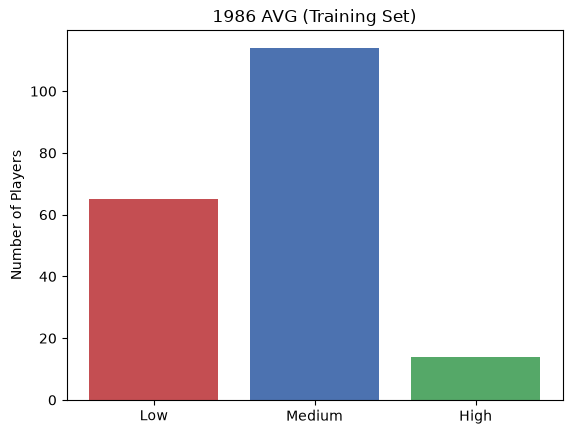

In [60]:



plt.bar(counts.index, counts.values, color=["#C44E52", "#4C72B0", "#55A868"])

plt.title("1986 AVG (Training Set)")
plt.ylabel("Number of Players")

plt.xticks(counts.index, ["Low", "Medium", "High"])

plt.show()

### Did we use the depth method or width method for creating these bins? Explain.

Width because the bins are partitioned by a specific "width" instead of putting a certain number of items in each bin.